In [3]:
from inception.instruments import TensorExtensionInterpolator, AutoCallableNoteChebyshev
from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.instruments import Stock, Portfolio
from inception.instruments.meta_instrument import Greeks

from env.environment import TradingEnv
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
from pandas_datareader import data as pdr

import yfinance as yf
yf.pdr_override() # <== that's all it takes :-)

# download dataframe
data_dia = pdr.get_data_yahoo("DIA", start="2014-01-01", end="2024-03-01")
data_spy = pdr.get_data_yahoo("SPY", start="2014-01-01", end="2024-03-01")
data_xlv = pdr.get_data_yahoo("XLV", start="2014-01-01", end="2024-03-01")

log_return = np.c_[np.diff(np.log(data_dia.Close)), np.diff(np.log(data_spy.Close)), np.diff(np.log(data_xlv.Close))]
log_df = pd.DataFrame(log_return)
corr_matrix = np.corrcoef(log_df.T)
corr_matrix

In [2]:
stock_price=[382.82, 494.08, 142.864]
evaluate_date='2024-02-14'

start_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
stock_name = ['A', 'B', 'C']

In [4]:
notes_database = './autocallable_database/'
interpolator = TensorExtensionInterpolator(notes_database)
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']

notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                    evaluate_date=evaluate_date,
                                    underlying_names=stock_name,
                                    stock_price=stock_price,
                                    vol=index_vol,
                                    issue_price=issued_price,
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=risk_free_rate,
                                    volume=-1)

t1 = time.time()
print('Value :', notes_c.value)
print('Delta :', notes_c.delta)
print('Gamma :', notes_c.gamma)
print(f'Total time: {time.time() - t1}')

Value : -102.02403613875728
Delta : A: -0.0016572161647226637, B: -0.0018661000262932864, C: -0.024443680894520606
Gamma : A: -3.3341452085727406e-05, B: 3.2979159390644784e-05, C: 0.0016980999104138836
Total time: 0.0580296516418457


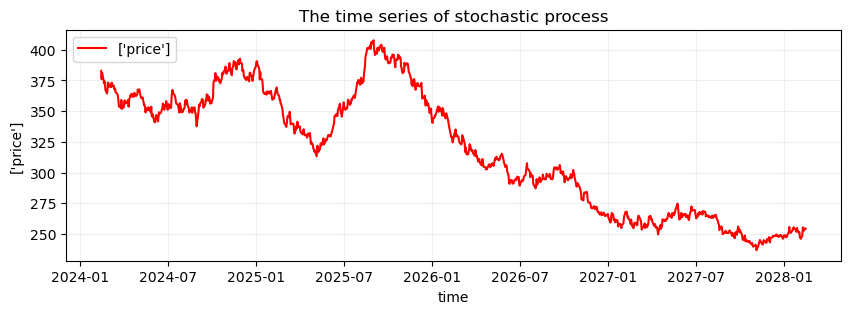

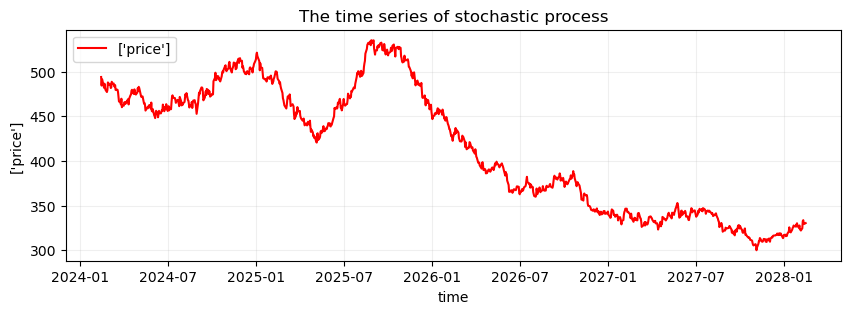

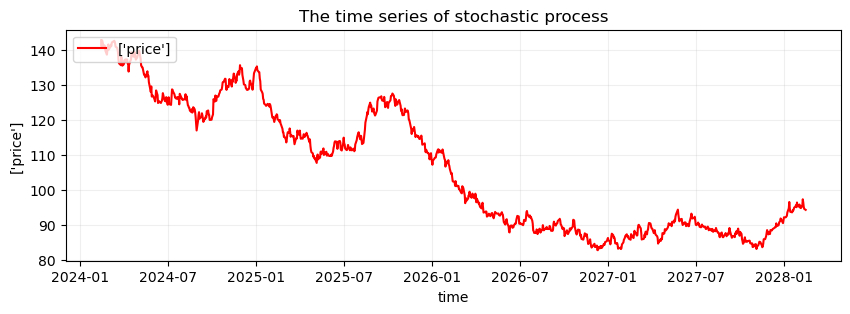

In [5]:
stock_A = Stock(stock_price[0], stock_mean[0], index_vol[0], evaluate_date, jump_weekend=True, name=stock_name[0],
                seed=2)
stock_B = Stock(stock_price[1], stock_mean[1], index_vol[1], evaluate_date, jump_weekend=True, name=stock_name[1],
                correlation=0.96, seed=2+1_000_000)
stock_C = Stock(stock_price[2], stock_mean[2], index_vol[2], evaluate_date, jump_weekend=True, name=stock_name[2],
                correlation=0.82, seed=2+2_000_000)

portfolio = Portfolio()

[stock_A.attach(stock) for stock in [stock_B, stock_C]]
[stock.attach(notes_c) for stock in [stock_A, stock_B, stock_C]]
notes_c.attach(portfolio)

for _ in range(1500):
    stock_A.update()
    if notes_c.is_expired:
        break
    
stock_A.draw('price')
stock_B.draw('price')
stock_C.draw('price')


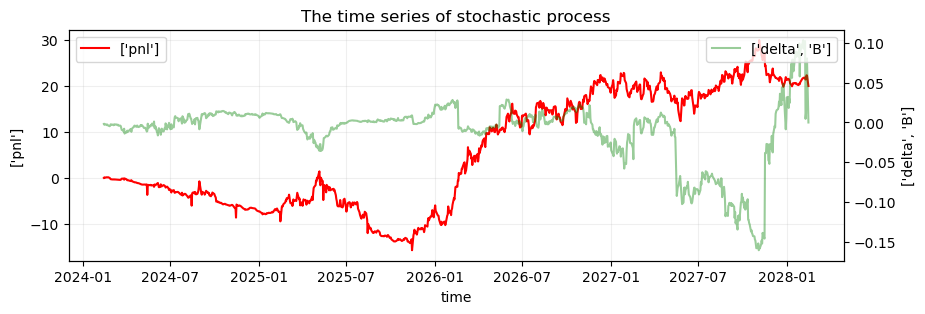

In [6]:
portfolio.draw('pnl', 'delta.B')

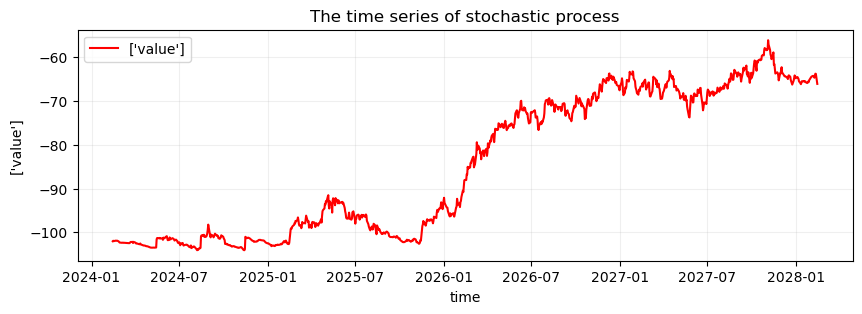

In [7]:
notes_c.draw('value')

## No Hedging Simulation

In [8]:
hedge_option_tenor = 30
transaction_cost = 0.02

trading_env = TradingEnv(stock_mean,
                         index_vol, 
                         stock_price, 
                         stock_name,
                         start_date,
                         risk_free_rate,
                         [],
                         [1],
                         hedge_option_tenor,
                         parameters['valuation dates'],
                         parameters['coupon dates'],
                         parameters['call dates'],
                         parameters['coupon barrier'],
                         parameters['principal barrier'],
                         parameters['call barrier'],
                         parameters['coupon amount'],
                         hedging_date=5,
                         notes_database_dir=notes_database,
                         transaction_cost=transaction_cost)

In [9]:
results = []
portfolios = []

for _ in tqdm(range(5000)):
    result = []
    trading_env.reset()
    while True:
        # Action is 0 means delta hedge
        action = [0]
        states, reward, done, info = trading_env.step(action)
        result.append([states, reward])
        if done:
            portfolios.append(trading_env.portfolio)
            break
    results.append(result)

  2%|█▍                                                                         | 98/5000 [1:04:20<32:03:06, 23.54s/it]

The 0th variable is 576.0737, and larger than the upper bound 574.23
The 1th variable is 741.1279, and larger than the upper bound 741.12
The 0th variable is 579.5278999999999, and larger than the upper bound 574.23
The 1th variable is 746.9859, and larger than the upper bound 741.12
The 0th variable is 575.08, and larger than the upper bound 574.23
The 0th variable is 580.8308000000001, and larger than the upper bound 574.23
The 0th variable is 575.08, and larger than the upper bound 574.23
The 1th variable is 746.1880000000001, and larger than the upper bound 741.12
The 0th variable is 575.08, and larger than the upper bound 574.23
The 0th variable is 575.08, and larger than the upper bound 574.23
The 0th variable is 575.08, and larger than the upper bound 574.23
The 0th variable is 576.96, and larger than the upper bound 574.23
The 0th variable is 582.7296, and larger than the upper bound 574.23
The 0th variable is 576.96, and larger than the upper bound 574.23
The 1th variable is 7

The 0th variable is 587.2342, and larger than the upper bound 574.23
The 1th variable is 760.46, and larger than the upper bound 741.12
The 0th variable is 575.6058, and larger than the upper bound 574.23
The 1th variable is 760.46, and larger than the upper bound 741.12
The 0th variable is 581.42, and larger than the upper bound 574.23
The 1th variable is 768.0646, and larger than the upper bound 741.12
The 0th variable is 581.42, and larger than the upper bound 574.23
The 1th variable is 752.8554, and larger than the upper bound 741.12
The 0th variable is 581.42, and larger than the upper bound 574.23
The 1th variable is 760.46, and larger than the upper bound 741.12
The 0th variable is 581.42, and larger than the upper bound 574.23
The 1th variable is 760.46, and larger than the upper bound 741.12
The 0th variable is 576.15, and larger than the upper bound 574.23
The 1th variable is 752.24, and larger than the upper bound 741.12
The 0th variable is 581.9114999999999, and larger than

The 0th variable is 577.15, and larger than the upper bound 574.23
The 1th variable is 757.27, and larger than the upper bound 741.12
The 0th variable is 582.9214999999999, and larger than the upper bound 574.23
The 1th variable is 757.27, and larger than the upper bound 741.12
The 1th variable is 757.27, and larger than the upper bound 741.12
The 0th variable is 577.15, and larger than the upper bound 574.23
The 1th variable is 764.8427, and larger than the upper bound 741.12
The 0th variable is 577.15, and larger than the upper bound 574.23
The 1th variable is 749.6973, and larger than the upper bound 741.12
The 0th variable is 577.15, and larger than the upper bound 574.23
The 1th variable is 757.27, and larger than the upper bound 741.12
The 0th variable is 577.15, and larger than the upper bound 574.23
The 1th variable is 757.27, and larger than the upper bound 741.12
The 0th variable is 583.1, and larger than the upper bound 574.23
The 1th variable is 766.1700000000001, and large

The 0th variable is 581.44, and larger than the upper bound 574.23
The 1th variable is 760.22, and larger than the upper bound 741.12
The 0th variable is 587.2544, and larger than the upper bound 574.23
The 1th variable is 760.22, and larger than the upper bound 741.12
The 0th variable is 575.6256000000001, and larger than the upper bound 574.23
The 1th variable is 760.22, and larger than the upper bound 741.12
The 0th variable is 581.44, and larger than the upper bound 574.23
The 1th variable is 767.8222000000001, and larger than the upper bound 741.12
The 0th variable is 581.44, and larger than the upper bound 574.23
The 1th variable is 752.6178000000001, and larger than the upper bound 741.12
The 0th variable is 581.44, and larger than the upper bound 574.23
The 1th variable is 760.22, and larger than the upper bound 741.12
The 0th variable is 581.44, and larger than the upper bound 574.23
The 1th variable is 760.22, and larger than the upper bound 741.12
The 1th variable is 751.75,

...

 95%|███████████████████████████████████████████████████████████████████████▏   | 4745/5000 [23:28:42<45:36, 10.73s/it]

The 2th variable is 215.4128, and larger than the upper bound 214.29000000000002


 99%|██████████████████████████████████████████████████████████████████████████▍| 4960/5000 [25:11:53<17:09, 25.73s/it]

The 1th variable is 745.7335, and larger than the upper bound 741.12
The 1th variable is 743.1681000000001, and larger than the upper bound 741.12
The 1th variable is 745.38, and larger than the upper bound 741.12


100%|███████████████████████████████████████████████████████████████████████████| 5000/5000 [25:19:34<00:00, 18.23s/it]


In [15]:
def result_processing(pnl_list: list, quantile_list: list) -> pd.DataFrame:
    """
    Process result
    :param pnl_list: The list of pnl of all simulation
    :param quantile_list
    """
    pnl = np.array(pnl_list)
    result = {'mean': pnl.mean(),
              'std': pnl.std(),
              'Mean-SD': pnl.mean() - 1.645 * pnl.std()}

    for q in quantile_list:
        var = np.quantile(pnl, 1 - q)
        result[f'var{q * 100:.0f}'] = var
        result[f'cvar{q * 100:.0f}'] = pnl[pnl <= var].mean()

    return pd.DataFrame([result])


In [16]:
episode_pnl_delta = pd.DataFrame([[res[1] for res in result] for result in results]).sum(axis=1)

In [17]:
result_processing(episode_pnl_delta, [0.05, 0.1, 0.9, 0.95])

,mean,std,Mean-SD,var5,cvar5,var10,cvar10,var90,cvar90,var95,cvar95
0,-7.215131,16.32948,-34.077126,26.266238,-9.47706,12.747001,-11.122161,-32.100964,-33.617631,-34.375964,-34.375964


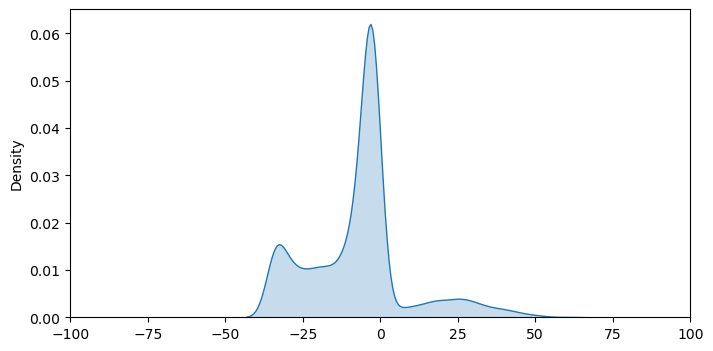

In [18]:
_ = plt.figure(figsize=(8, 4))
_ = sb.kdeplot(episode_pnl_delta,fill=True)
_ = plt.xlim([-100, 100])

In [34]:
portfolios[1].risk

,pnl,delta,gamma,daily_cash,value,vega,rho,daily_pnl
2024-02-14,0.0,"A: -0.001657197454268189, B: -0.00186604353729...","A: -3.3340819804632676e-05, B: 3.2983411410382...",102.023939,-102.023939,0.0,0.0,0.0
2024-02-15,0.112883,"B: -0.0028078254792926133, C: -0.0299288225131...","B: 0.00014480878023949255, C: 0.00233729400924...",0,-101.911056,0.0,0.0,0.112883
2024-02-16,0.022101,"B: -0.0019991063234307883, C: -0.0240133665381...","B: 5.3842184394912314e-05, C: 0.00165279710013...",0,-102.001838,0.0,0.0,-0.090782
2024-02-19,0.093584,"B: -0.002730559718855882, C: -0.02827892849440...","B: 0.0001376706763820567, C: 0.002172229851771...",0,-101.930355,0.0,0.0,0.071483
2024-02-20,0.138625,"B: -0.0033058332209720993, C: -0.0311465901679...","B: 0.00018743698806922732, C: 0.00248595287413...",0,-101.885314,0.0,0.0,0.045041
...,...,...,...,...,...,...,...,...
2028-02-08,21.432477,"B: 0.004608016443691878, C: -0.299499972398001...","B: -0.005597274387165406, C: 0.000110657014767...",0.0,-64.666462,0.0,0.0,-0.408445
2028-02-09,21.78669,"B: 0.01123037755187644, C: -0.351128448473172,...","B: -0.0046421666610946145, C: -0.0112649798163...",0,-64.312249,0.0,0.0,0.354213
2028-02-10,22.355363,"B: 0.07774903878903339, C: -0.127973977853614,...","B: -0.00034705187129284237, C: -0.020410959141...",0,-63.743576,0.0,0.0,0.568673
2028-02-11,22.306275,"B: 0.08050421753505593, C: -0.0922810462865437...","B: 0.0007151276841435195, C: -0.02511972356951...",0,-63.792664,0.0,0.0,-0.049088


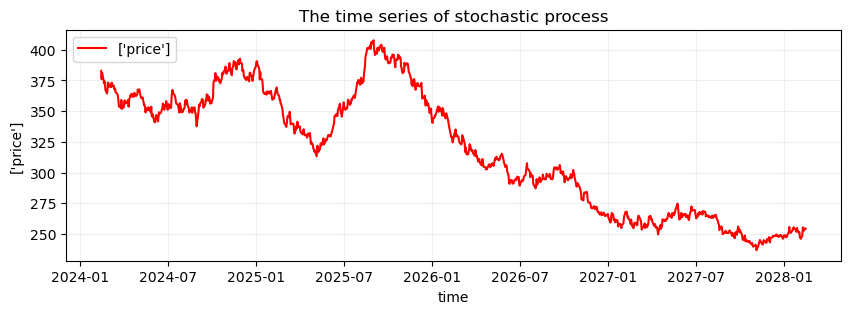

In [37]:
trading_env.stock_A.draw('price')

In [21]:
b = episode_pnl_delta.copy()

In [29]:
b.sort_values().iloc[-540:]

1447     9.774975
1913     9.813625
1326     9.851368
3294     9.906598
3295     9.946415
          ...    
1499    54.593985
598     54.809518
1615    59.990228
128     61.893345
2213    63.539665
Length: 540, dtype: float64

In [53]:
portfolios[1447].position[3].lines['coupon'][-10:]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [56]:
portfolios[1447].position[3].value+102+sum(portfolios[1447].position[3].lines['coupon'])

9.750939119170976

In [48]:
portfolios[1447].position[1].return_ratio()

-0.37325939119170976

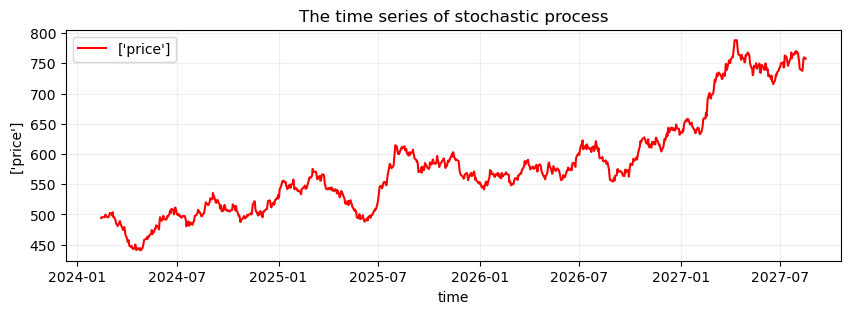

In [65]:
portfolios[2282].position[1].draw('price')